In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## ETL Phase

In [2]:
#importing data
spotify_origin = pd.read_csv("C:\\Users\\ihsan\\Data Analysis\\Most Streamed Artists on Spotify\\Data\\Most Streamed Artists on Spotify (17_07_2026) V1.1.csv")

#making copy of the dataframe to preserve the original copy
spotify = spotify_origin.copy()

#checking df shape
spotify.shape


(500, 14)

In [3]:
#previewing df

spotify_origin.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [4]:
#Checking for missing data
spotify.isna().sum()

Artist Name                            0
Sex                                    0
Country of Origin                      0
Primary Language                       0
Primary Genre                          0
 Artist Type                           0
Debut Year                             0
Total Streams (in millions)            0
Lead Streams (in millions)             0
Feature Streams (in millions)          0
Solo Streams (in millions)             0
% of Solo Streams                      0
Collaborative Streams (in millions)    0
% of Collaborative Streams             0
dtype: int64

In [5]:
#previewing dtypes to check wether some column need to be adjusted
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5    Artist Type                         500 non-null    object 
 6   Debut Year                           500 non-null    int64  
 7   Total Streams (in millions)          500 non-null    float64
 8   Lead Streams (in millions)           500 non-null    float64
 9   Feature Streams (in millions)        500 non-null    float64
 10  Solo Streams (in millions)           500 non-null    float64
 11  % of Solo Streams               

In [6]:
spotify['Sex'].unique()

array(['Male', 'Female', 'Mixed'], dtype=object)

In [7]:
spotify['Country of Origin'].value_counts()

Country of Origin
United States          265
United Kingdom          55
Mexico                  27
Canada                  18
Colombia                16
Brazil                  15
India                   13
South Korea             11
Argentina                9
Australia                7
Germany                  7
Spain                    6
Sweden                   5
France                   5
Ireland                  4
Italy                    3
Japan                    2
Scotland                 2
Jamaica                  2
Nigeria                  2
Dominican Republic       2
Norway                   2
Netherlands              2
Barbados                 1
Trinidad and Tobago      1
Panama                   1
Cuba                     1
Morocco                  1
New Zealand              1
Senegal                  1
Chile                    1
South Africa             1
Russia                   1
Venezuela                1
Belgium                  1
DR Congo                 1
Nepal     

In [8]:
spotify['Primary Language'].unique()

array(['English', 'Spanish', 'Korean', 'Hindi', 'German', 'Portuguese',
       'Tamil', 'French', 'Italian', 'Urdu', 'Punjabi'], dtype=object)

In [9]:
spotify['Primary Genre'].unique()

array(['Hip-Hop', 'Pop', 'Reggaeton', 'R&B', 'K-Pop', 'Rock',
       'Alternative', 'EDM', 'Filmi', 'Latin', 'Regional Mexican',
       'Country', 'Spoken Word', 'Soundtrack', 'Bachata', 'Sertanjeo',
       'Reggae', 'Folk', 'Metal', 'Afrobeats', 'Soul', "Children's Music",
       'Nu Metal'], dtype=object)

In [10]:
spotify[' Artist Type'].unique()

array(['Solo', 'Group'], dtype=object)

In [11]:
#fixing Artist Type column name

spotify['Artist Type'] = spotify[' Artist Type']

spotify = spotify.drop(columns=' Artist Type')

#checking
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Artist Name                          500 non-null    object 
 1   Sex                                  500 non-null    object 
 2   Country of Origin                    500 non-null    object 
 3   Primary Language                     500 non-null    object 
 4   Primary Genre                        500 non-null    object 
 5   Debut Year                           500 non-null    int64  
 6   Total Streams (in millions)          500 non-null    float64
 7   Lead Streams (in millions)           500 non-null    float64
 8   Feature Streams (in millions)        500 non-null    float64
 9   Solo Streams (in millions)           500 non-null    float64
 10  % of Solo Streams                    500 non-null    float64
 11  Collaborative Streams (in millio

Country of Origin, Primary Language, Primary Genre and Artist Type would be better as a categorical data types. Also, it seems in the Country of origin column it would be better to collapse some country into other. The reason is that, when modelling the data it would reduce dimensionality problems.

I have decided to use 1% as a threshold in collapsing some values in Country of Origin column. The reasoning behind that is, in k-fold it is required that the instances of a value in order to be meaningful is 5 or 10 times. Since this data is quite small (only 500 records), I decided to pick up the 5 instances or 1% of the total data count. 

Some categorical column might also have this problem so below i would check all of them again.

But first, reordering the column so its gonna be like the original order

In [12]:
# Getting collumn name to copy paste
spotify.columns

Index(['Artist Name', 'Sex', 'Country of Origin', 'Primary Language',
       'Primary Genre', 'Debut Year', 'Total Streams (in millions)',
       'Lead Streams (in millions)', 'Feature Streams (in millions)',
       'Solo Streams (in millions)', '% of Solo Streams',
       'Collaborative Streams (in millions)', '% of Collaborative Streams',
       'Artist Type'],
      dtype='object')

In [13]:
spotify = spotify[['Artist Name', 'Sex', 'Country of Origin', 'Primary Language',
       'Primary Genre', 'Artist Type', 'Debut Year', 'Total Streams (in millions)',
       'Lead Streams (in millions)', 'Feature Streams (in millions)',
       'Solo Streams (in millions)', '% of Solo Streams',
       'Collaborative Streams (in millions)', '% of Collaborative Streams']]

In [14]:
spotify.head()

,Artist Name,Sex,Country of Origin,Primary Language,Primary Genre,Artist Type,Debut Year,Total Streams (in millions),Lead Streams (in millions),Feature Streams (in millions),Solo Streams (in millions),% of Solo Streams,Collaborative Streams (in millions),% of Collaborative Streams
0,Drake,Male,Canada,English,Hip-Hop,Solo,2006,137492.1,94851.1,42640.9,53323.9,38.783246,84168.2,61.216754
1,Taylor Swift,Female,United States,English,Pop,Solo,2006,127861.0,126177.3,1683.8,113421.5,88.706877,14439.5,11.293123
2,Bad Bunny,Male,United States,Spanish,Reggaeton,Solo,2013,125899.8,82189.3,43710.5,48887.0,38.830086,77012.8,61.169914
3,The Weeknd,Male,Canada,English,R&B,Solo,2009,95703.2,77189.4,18513.8,51020.0,53.310652,44683.2,46.689348
4,Justin Bieber,Male,Canada,English,Pop,Solo,2009,78104.4,48316.2,29788.2,29638.3,37.947030,48466.1,62.052970


In [15]:
spotify['Sex'].value_counts()

Sex
Male      390
Female     88
Mixed      22
Name: count, dtype: int64

In [16]:
spotify['Primary Language'].value_counts()

Primary Language
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
German          7
French          4
Italian         3
Tamil           2
Urdu            1
Punjabi         1
Name: count, dtype: int64

In [17]:
spotify['Primary Genre'].value_counts()

Primary Genre
Hip-Hop             115
Pop                 102
Rock                 60
Reggaeton            43
R&B                  31
Latin                30
EDM                  22
Regional Mexican     19
K-Pop                11
Filmi                11
Country              10
Alternative           9
Sertanjeo             9
Metal                 8
Folk                  4
Soundtrack            3
Bachata               3
Soul                  3
Reggae                2
Afrobeats             2
Spoken Word           1
Children's Music      1
Nu Metal              1
Name: count, dtype: int64

In [18]:
spotify['Artist Type'].value_counts()

Artist Type
Solo     373
Group    127
Name: count, dtype: int64

Primary language & Primary Genre also has the same problem. So, i would also colapse some value with other in those columns.

In [19]:
# Define the columns you want to process and the threshold

columns_to_collapse = ['Country of Origin', 'Primary Language', 'Primary Genre']
threshold = 0.01

# Loop through each specified column
for col in columns_to_collapse:
    
    # Calculate frequencies for the current column
    frequencies = spotify[col].value_counts(normalize=True)
    
    # Identify categories that fall below the 1% threshold
    rare_categories = frequencies[frequencies < threshold].index
    
    # Replace the rare categories with 'Other'
    spotify[col] = spotify[col].replace(rare_categories, 'Other')
    
    # Optional: Print a quick summary to check the results for each column
    print(f"\n--- Categories for {col} after collapsing ---")
    print(spotify[col].value_counts())
    print(f"Number of unique categories reduced to: {spotify[col].nunique()}")


--- Categories for Country of Origin after collapsing ---
Country of Origin
United States     265
United Kingdom     55
Other              41
Mexico             27
Canada             18
Colombia           16
Brazil             15
India              13
South Korea        11
Argentina           9
Germany             7
Australia           7
Spain               6
France              5
Sweden              5
Name: count, dtype: int64
Number of unique categories reduced to: 15

--- Categories for Primary Language after collapsing ---
Primary Language
English       340
Spanish       105
Portuguese     15
Korean         11
Hindi          11
Other          11
German          7
Name: count, dtype: int64
Number of unique categories reduced to: 7

--- Categories for Primary Genre after collapsing ---
Primary Genre
Hip-Hop             115
Pop                 102
Rock                 60
Reggaeton            43
R&B                  31
Latin                30
EDM                  22
Other             

In [20]:
#Changing into categorical dytpe 

spotify['Sex'] = spotify['Sex'].astype('category')
spotify['Primary Language'] = spotify['Primary Language'].astype('category')
spotify['Primary Genre'] = spotify['Primary Genre'].astype('category')
spotify['Country of Origin'] = spotify['Country of Origin'].astype('category')
spotify['Artist Type'] = spotify['Artist Type'].astype('category')

In [21]:
spotify.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 14 columns):
 #   Column                               Non-Null Count  Dtype   
---  ------                               --------------  -----   
 0   Artist Name                          500 non-null    object  
 1   Sex                                  500 non-null    category
 2   Country of Origin                    500 non-null    category
 3   Primary Language                     500 non-null    category
 4   Primary Genre                        500 non-null    category
 5   Artist Type                          500 non-null    category
 6   Debut Year                           500 non-null    int64   
 7   Total Streams (in millions)          500 non-null    float64 
 8   Lead Streams (in millions)           500 non-null    float64 
 9   Feature Streams (in millions)        500 non-null    float64 
 10  Solo Streams (in millions)           500 non-null    float64 
 11  % of Solo Streams  

Much better!

In [90]:
# Apply the theme
viridis_discrete = sns.color_palette("viridis", 6)

sns.set_theme(style="whitegrid", palette=viridis_discrete, font="sans-serif")

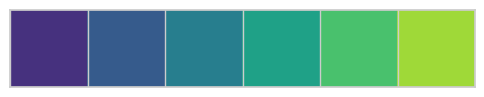

In [92]:
sns.palplot(viridis_discrete)
plt.show()

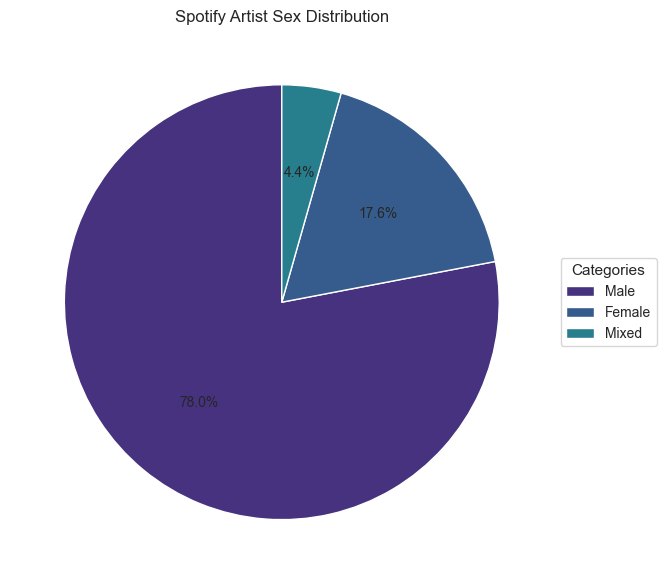

In [95]:
# Making pie chart to visualize operation system distribution

# making value counts so it could be visualized properly
class_counts = spotify['Sex'].value_counts()

labels = class_counts.index
values = class_counts.values

# Create a custom formatting function
def top_3_autopct(pct):
    # Calculate the raw count from the percentage
    total = sum(values)
    val = int(round(pct * total / 100.0))
    return f'{pct:.1f}%'

# Plot the pie chart using the custom function
plt.figure(figsize=(8, 6))
plt.pie(
    values,
    autopct=top_3_autopct,
    startangle=90, 
    textprops={'fontsize': 10}
)

# Customizing the legend
plt.legend(labels, 
           title="Categories", 
           loc="center left", 
           bbox_to_anchor=(1, 0.5), 
           fontsize=10, 
           title_fontsize=11)

plt.title('Spotify Artist Sex Distribution')
plt.tight_layout()
plt.show()

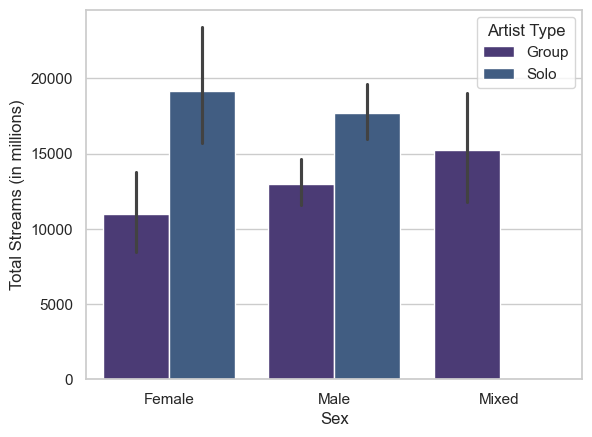

In [94]:
sns.barplot(x='Sex', y='Total Streams (in millions)', hue='Artist Type', data=spotify)
plt.show()